vmax: 316.1180679441437


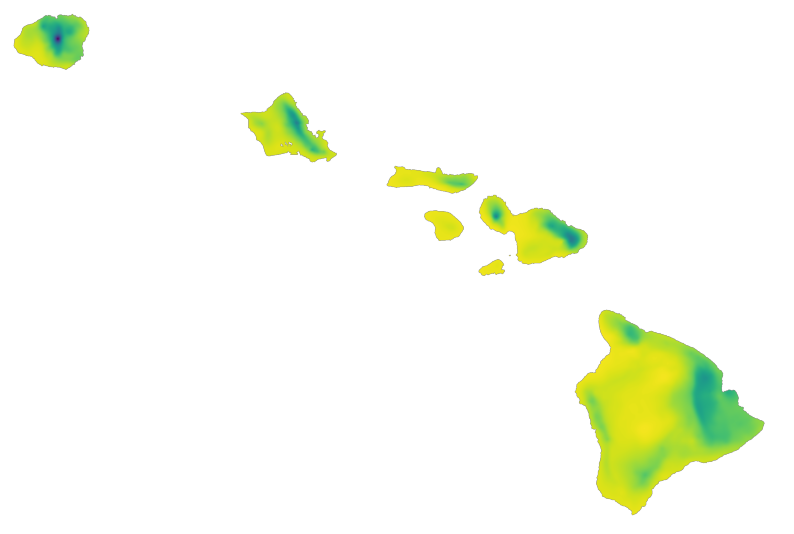

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

out_png = "../../public/climate-summary/annual_rainfall_2025_agg.png"

with rasterio.open("annual_rainfall_2025_agg.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data) / 25.4

vmax = np.nanmax(masked)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'viridis_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin=0,
    vmax=vmax,
)
print(f"vmax: {vmax}")
ax.set_axis_off()  # removes ticks + border/frame
# cbar = fig.colorbar(im, ax=ax)
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()


vmax: 107.88154602050781


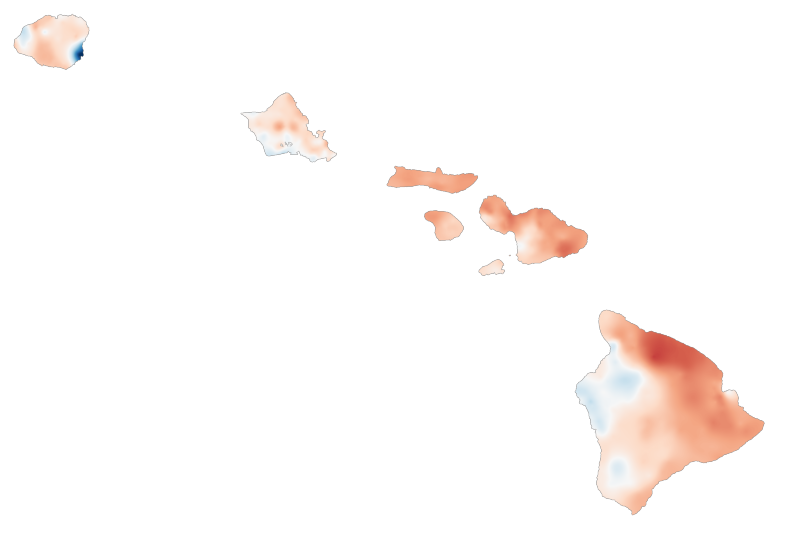

In [4]:
out_png = "../../public/climate-summary/annual_rainfall_2025_pdiff.png"

with rasterio.open("annual_rainfall_2025_pdiff.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data) 

vmax = np.nanmax(masked)
print(f"vmax: {vmax}")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'RdBu',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin=-100,
    vmax=100,
)
ax.set_axis_off()  # removes ticks + border/frame
# cbar = fig.colorbar(im, ax=ax)
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()


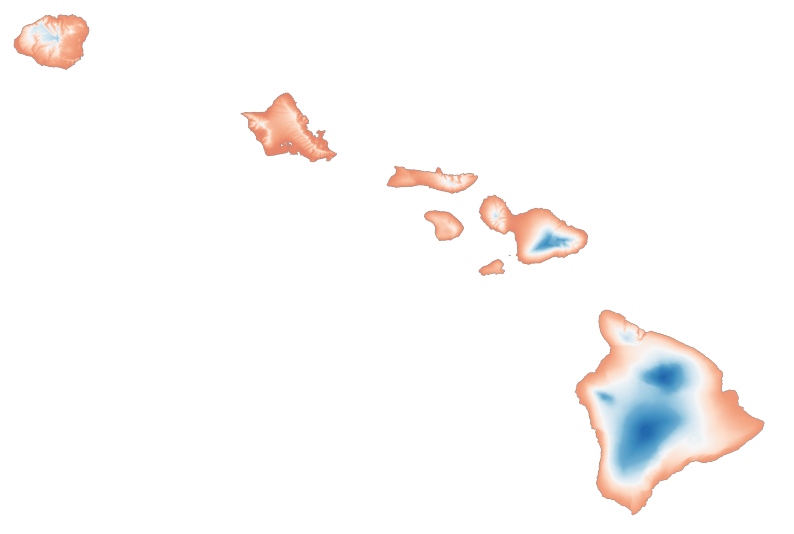

In [5]:
out_png = "../../public/climate-summary/annual_tmean_2025_agg.png"

with rasterio.open("annual_tmean_2025_agg.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data)*9/5 + 32  # C to F


fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'RdBu_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin = 40,
    vmax = 90,
)
ax.set_axis_off()  # removes ticks + border/frame

# cbar = fig.colorbar(im)
# cbar.set_label("Mean temperature (deg F)")

# print(f"Vabs: {vabs}")
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()




Vabs: 1.5372934341430664


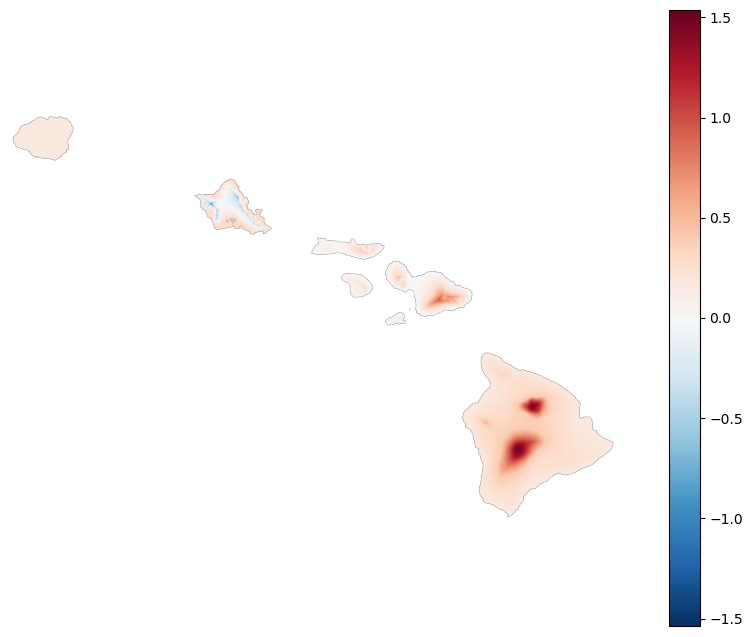

In [6]:
out_png = "../../public/climate-summary/annual_tmean_2024_anomaly.png"

with rasterio.open("annual_tmean_2024_anomaly.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data)

vmin = np.nanmin(masked)
vmax = np.nanmax(masked)

vabs = max(abs(vmin), abs(vmax))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'RdBu_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin = -vabs,
    vmax = vabs,
)
ax.set_axis_off()  # removes ticks + border/frame

cbar = fig.colorbar(im)
# cbar.set_label("Mean temperature (deg F)")

print(f"Vabs: {vabs}")
# fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()




In [3]:
import pandas as pd
rf_monthly = []
t_monthly = []
for m in range(1,13):
    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/rainfall/rainfall_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data) / 25.4

    rfmean = masked.mean()
    rf_monthly.append(rfmean)

    with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_2025_{m:02d}.tif') as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        masked = np.ma.masked_where(data == nodata, data)*9/5 + 32

    tmean = masked.mean()
    t_monthly.append(tmean)

pd.DataFrame({
    'month': range(1,13),
    'rf_mean': rf_monthly,
    'tmean': t_monthly,
}).to_csv('../../public/climate-summary/monthly_summary.csv', index=False)

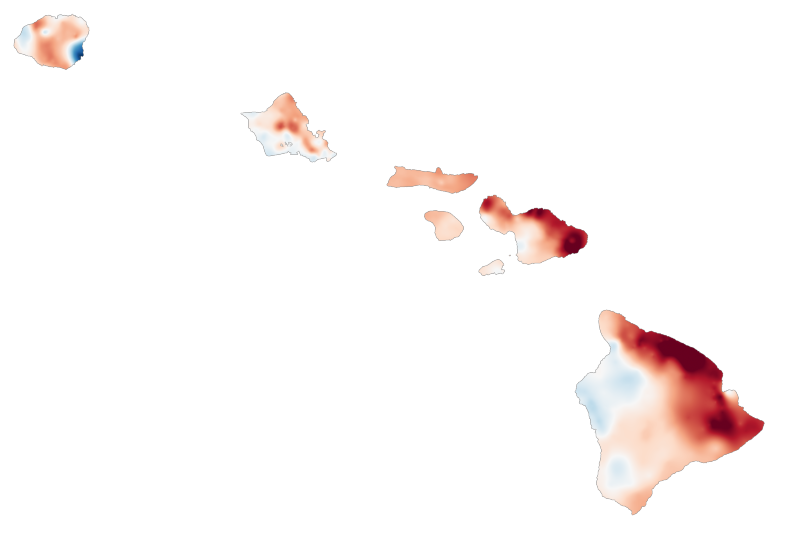

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

out_png = "../../public/climate-summary/spi12.png"

with rasterio.open("spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data) 


fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'RdBu',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin=-3,
    vmax=3,
)

ax.set_axis_off()  # removes ticks + border/frame
# cbar = fig.colorbar(im, ax=ax)
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()
